# Turmeric Quality Classification using CNN and Machine Learning Features

This Jupyter notebook walks through the entire pipeline for classifying turmeric quality into **Good** (high quality, deep orange-yellow) and **Bad** (low quality, moldy, greyish, or adulterated). 

### Project Overview:
1. **Dataset Loading & Preprocessing**: Loading synthetic turmeric images, resizing, and normalizing.
2. **Traditional ML Feature Extraction**: Extracting color statistics (RGB and HSV mean/std-dev) which are highly indicative of turmeric purity.
3. **Deep Learning Model (CNN)**: Building, training, and evaluating a Convolutional Neural Network from scratch.
4. **Hybrid Model (CNN + ML Features)**: Extracting deep features from the trained CNN, concatenating them with color statistics, and training a Support Vector Machine (SVM) classifier.
5. **Serialization (Pickle & Keras)**: Saving the models and preprocess pipelines for Streamlit integration.

## Step 0: Import Libraries

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0


Num GPUs Available: 0


## Step 1: Define Constants and Paths

In [2]:
DATASET_DIR = "dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 128  # Resize dimensions for the CNN
CLASSES = ["good", "bad"]
print(f"Classes: {CLASSES}")

Classes: ['good', 'bad']


## Step 2: Feature Extraction and Preprocessing Functions

We extract two types of features:
1. **Traditional ML Features**: Mean and standard deviation of color channels in both **RGB** and **HSV** color spaces. (12 features total)
2. **CNN Features**: Image arrays preprocessed for deep learning model input.

In [3]:
def extract_color_features(img_path):
    """Extracts average color and variance features in RGB and HSV color spaces."""
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # Convert to RGB and HSV
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Calculate mean and standard deviation for each channel
    mean_rgb, std_rgb = cv2.meanStdDev(img_rgb)
    mean_hsv, std_hsv = cv2.meanStdDev(img_hsv)
    
    # Flatten the arrays to get 1D features
    features = np.hstack([
        mean_rgb.flatten(), # [Mean R, Mean G, Mean B]
        std_rgb.flatten(),  # [Std R, Std G, Std B]
        mean_hsv.flatten(), # [Mean H, Mean S, Mean V]
        std_hsv.flatten()   # [Std H, Std S, Std V]
    ])
    return features

def load_dataset_from_disk(base_dir):
    """Loads image paths, labels, and traditional color features."""
    images = []
    color_features = []
    labels = []
    filepaths = []
    
    for class_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(base_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            
            # Load for CNN (resized and normalized)
            try:
                img = Image.open(img_path).convert('RGB')
                img_resized = img.resize((IMG_SIZE, IMG_SIZE))
                img_array = np.array(img_resized) / 255.0  # Normalization
                
                # Extract traditional ML color features
                c_feat = extract_color_features(img_path)
                if c_feat is not None:
                    images.append(img_array)
                    color_features.append(c_feat)
                    labels.append(class_idx)
                    filepaths.append(img_path)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(color_features), np.array(labels), filepaths

## Step 3: Load Data

In [4]:
print("Loading Training Data...")
X_train_img, X_train_color, y_train, train_paths = load_dataset_from_disk(TRAIN_DIR)

print("Loading Testing Data...")
X_test_img, X_test_color, y_test, test_paths = load_dataset_from_disk(TEST_DIR)

print(f"\nTrain Images shape: {X_train_img.shape}")
print(f"Train Color features shape: {X_train_color.shape}")
print(f"Test Images shape: {X_test_img.shape}")
print(f"Test Color features shape: {X_test_color.shape}")

Loading Training Data...


Loading Testing Data...

Train Images shape: (120, 128, 128, 3)
Train Color features shape: (120, 12)
Test Images shape: (30, 128, 128, 3)
Test Color features shape: (30, 12)


## Step 4: Visualize Samples & Color Features

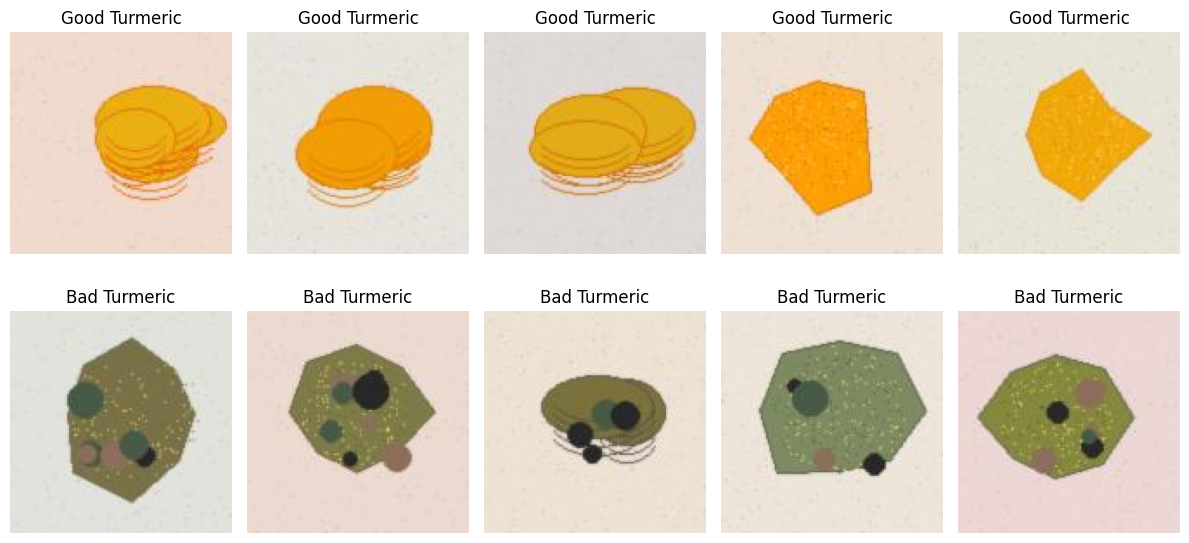

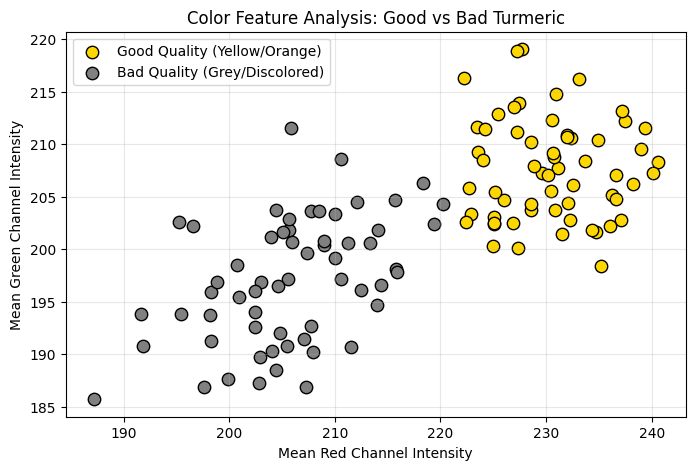

In [5]:
# Plot sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(5):
    # Good quality sample
    good_indices = np.where(y_train == 0)[0]
    axes[0, i].imshow(X_train_img[good_indices[i]])
    axes[0, i].set_title("Good Turmeric")
    axes[0, i].axis('off')
    
    # Bad quality sample
    bad_indices = np.where(y_train == 1)[0]
    axes[1, i].imshow(X_train_img[bad_indices[i]])
    axes[1, i].set_title("Bad Turmeric")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Plot color feature distributions (Mean Red vs Mean Green)
plt.figure(figsize=(8, 5))
plt.scatter(X_train_color[y_train == 0, 0], X_train_color[y_train == 0, 1], label='Good Quality (Yellow/Orange)', color='gold', edgecolor='k', s=80)
plt.scatter(X_train_color[y_train == 1, 0], X_train_color[y_train == 1, 1], label='Bad Quality (Grey/Discolored)', color='grey', edgecolor='k', s=80)
plt.xlabel('Mean Red Channel Intensity')
plt.ylabel('Mean Green Channel Intensity')
plt.title('Color Feature Analysis: Good vs Bad Turmeric')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 5: Build and Train Custom CNN Classifier

In [6]:
def create_turmeric_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu', name='dense_features'), # We will extract features from here
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid') # Binary classifier: 0=good, 1=bad
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = create_turmeric_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train CNN
history = cnn_model.fit(
    X_train_img, y_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_test_img, y_test),
    verbose=1
)

Epoch 1/15


1/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4375 - loss: 0.6999

2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5000 - loss: 0.8355

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5417 - loss: 0.7567

4/8 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5312 - loss: 0.7584

...

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.0013

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.0011

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 9.5359e-04

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 9.0386e-04

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 1.0000 - loss: 9.0386e-04 - val_accuracy: 1.0000 - val_loss: 4.0310e-05


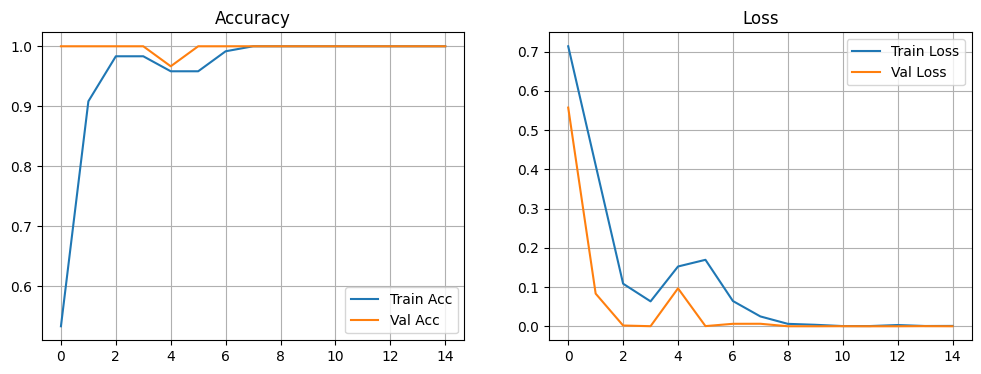

In [8]:
# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)
plt.show()

## Step 6: Evaluate CNN on Test Dataset

In [9]:
# Predict test set using CNN
y_pred_cnn_prob = cnn_model.predict(X_test_img)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).flatten()

print("--- CNN Classifier Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cnn, target_names=CLASSES))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cnn))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


--- CNN Classifier Results ---
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        good       1.00      1.00      1.00        15
         bad       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[15  0]
 [ 0 15]]


## Step 7: Train Traditional ML Classifier using Traditional ML Features

Now we train a standard Machine Learning model (Random Forest) solely on the 12 color histogram features.

In [10]:
# Standardize traditional color features
scaler_color = StandardScaler()
X_train_color_scaled = scaler_color.fit_transform(X_train_color)
X_test_color_scaled = scaler_color.transform(X_test_color)

# Train Random Forest
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42)
rf_classifier.fit(X_train_color_scaled, y_train)

# Evaluate
y_pred_rf = rf_classifier.predict(X_test_color_scaled)
print("--- Traditional ML Classifier (Color Features Only) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

--- Traditional ML Classifier (Color Features Only) ---
Accuracy: 1.0


## Step 8: Hybrid Model (CNN Deep Features + Traditional Color Features + SVM)

In this hybrid approach:
1. We use the trained CNN's second-to-last layer (`dense_features`) to extract a **64-dimensional deep feature vector** representing shape, texture, and complex patterns.
2. We concatenate this vector with our **12-dimensional color feature vector**.
3. We train a Support Vector Machine (SVM) on this combined feature vector (76 features total).

In [11]:
# Create feature extractor model from the CNN
feature_extractor = models.Sequential(cnn_model.layers[:-2])

# Extract deep features
print("Extracting deep features for Train and Test datasets...")
X_train_deep = feature_extractor.predict(X_train_img)
X_test_deep = feature_extractor.predict(X_test_img)

print("Deep Features Train shape:", X_train_deep.shape)

# Concatenate Deep features with scale-normalized Color features
X_train_hybrid = np.hstack([X_train_deep, X_train_color_scaled])
X_test_hybrid = np.hstack([X_test_deep, X_test_color_scaled])

print("Hybrid Features Train shape:", X_train_hybrid.shape)

# Train SVM on Hybrid features
scaler_hybrid = StandardScaler()
X_train_hybrid_scaled = scaler_hybrid.fit_transform(X_train_hybrid)
X_test_hybrid_scaled = scaler_hybrid.transform(X_test_hybrid)

svm_hybrid_classifier = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
svm_hybrid_classifier.fit(X_train_hybrid_scaled, y_train)

# Evaluate Hybrid model
y_pred_hybrid = svm_hybrid_classifier.predict(X_test_hybrid_scaled)
print("--- Hybrid (CNN + Color + SVM) Classifier Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hybrid, target_names=CLASSES))

Extracting deep features for Train and Test datasets...


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


Deep Features Train shape: (120, 64)
Hybrid Features Train shape: (120, 76)
--- Hybrid (CNN + Color + SVM) Classifier Results ---
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        good       1.00      1.00      1.00        15
         bad       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 9: Save Models & Preprocessing Objects using Pickle & Keras

To make the Streamlit UI function, it needs:
1. The Keras CNN model (specifically the feature extractor).
2. The Scalers (`scaler_color` and `scaler_hybrid`).
3. The SVM hybrid classifier.
4. The overall class mapping list.

We will dump the traditional ML components, scalers, and class mappings to a single Pickle file, and save the Keras CNN feature extractor to a `.keras` file.

In [12]:
# Save Keras CNN and Feature Extractor models
cnn_model.save("turmeric_cnn_full.keras")
feature_extractor.save("turmeric_cnn_feature_extractor.keras")
print("Keras models saved successfully.")

# Package the traditional ML components for Pickle
pipeline_data = {
    "scaler_color": scaler_color,
    "scaler_hybrid": scaler_hybrid,
    "svm_classifier": svm_hybrid_classifier,
    "classes": CLASSES,
    "img_size": IMG_SIZE
}

# Save using Pickle
with open("turmeric_classifier_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline_data, f)
print("Pickle file saved successfully: 'turmeric_classifier_pipeline.pkl'")

Keras models saved successfully.


Pickle file saved successfully: 'turmeric_classifier_pipeline.pkl'


## Step 10: Test loaded pickle and CNN model

Let's write a small verification code to make sure the saved files can load and make predictions together.

In [13]:
# Load files
with open("turmeric_classifier_pipeline.pkl", "rb") as f:
    saved_pipeline = pickle.load(f)

loaded_feat_extractor = tf.keras.models.load_model("turmeric_cnn_feature_extractor.keras")

# Choose a test image path
sample_image_path = test_paths[0]
print("Testing with image:", sample_image_path)

# Preprocess for CNN
test_img = Image.open(sample_image_path).convert('RGB')
test_img_resized = test_img.resize((saved_pipeline["img_size"], saved_pipeline["img_size"]))
test_img_array = np.array(test_img_resized) / 255.0
test_img_batch = np.expand_dims(test_img_array, axis=0)

# Extract deep features
sample_deep_feat = loaded_feat_extractor.predict(test_img_batch)

# Extract traditional features
sample_color_feat = extract_color_features(sample_image_path)
sample_color_scaled = saved_pipeline["scaler_color"].transform([sample_color_feat])

# Combine
sample_hybrid = np.hstack([sample_deep_feat, sample_color_scaled])
sample_hybrid_scaled = saved_pipeline["scaler_hybrid"].transform(sample_hybrid)

# Predict using the pickled SVM
pred_class_idx = saved_pipeline["svm_classifier"].predict(sample_hybrid_scaled)[0]
pred_probs = saved_pipeline["svm_classifier"].predict_proba(sample_hybrid_scaled)[0]
pred_class = saved_pipeline["classes"][pred_class_idx]

print(f"\nPrediction: {pred_class} (Confidence: {pred_probs[pred_class_idx]*100:.2f}%)")
print(f"True Label: {CLASSES[y_test[0]]}")

Testing with image: dataset\test\good\turmeric_good_000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step



Prediction: good (Confidence: 98.37%)
True Label: good
